# Covariance, Correlation, and Portfolio Diversification


This notebook demonstrates how asset co-movement is measured and why it matters for portfolio construction.

- Long and short positions in the same instrument move in opposite directions.
- Correlation measures whether assets tend to move together, independently, or in opposite directions.
- Covariance and correlation are core tools in portfolio management.
- Diversification benefits usually improve when combining assets with low or negative correlation.


## 1) Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except ModuleNotFoundError:
    SEABORN_AVAILABLE = False
    print('seaborn not available in this environment; using matplotlib heatmap fallback.')

pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')
if SEABORN_AVAILABLE:
    sns.set_theme(style='white')


seaborn not available in this environment; using matplotlib heatmap fallback.


## 2) Load Close Price Data


In [2]:
prices = pd.read_csv('close.csv', index_col='Date', parse_dates=['Date']).sort_index()
prices.head()


,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,108.406662,383.614990,1.262834,"1,214.599976",38.880169,"16,804.710938"
2014-10-02,107.971878,375.071991,1.262419,"1,214.199951",38.761570,"16,801.050781"
2014-10-03,109.876221,359.511993,1.267058,"1,192.199951",39.041100,"17,009.689453"
2014-10-04,NaN,328.865997,NaN,NaN,NaN,NaN
2014-10-05,NaN,320.510010,NaN,NaN,NaN,NaN


## 3) Add Inverse FX Series (If Available)

To illustrate long vs short symmetry, we create an inverse FX series `USDEUR = 1 / EURUSD` when an EUR/USD column is available.

If this series is created, we should observe a strong negative correlation between EURUSD and USDEUR returns.


In [3]:
fx_candidates = ['EURUSD', 'EURUSD=X', 'EUR/USD']
eurusd_col = next((col for col in fx_candidates if col in prices.columns), None)

if eurusd_col is not None:
    prices['USDEUR'] = 1 / prices[eurusd_col]
    print(f"Created USDEUR from '{eurusd_col}'.")
else:
    print('No EURUSD-style column found; skipping USDEUR creation.')

prices.tail()


Created USDEUR from 'EURUSD=X'.


,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR
Date,,,,,,,
2021-05-26,241.369995,"39,294.199219",1.224909,"1,901.300049",242.428955,"34,323.050781",0.816387
2021-05-27,250.699997,"38,436.968750",1.219260,"1,895.699951",240.327499,"34,464.640625",0.820170
2021-05-28,247.020004,"35,697.605469",1.219319,"1,902.500000",240.684158,"34,529.449219",0.820130
2021-05-29,NaN,"34,616.066406",NaN,NaN,NaN,NaN,NaN
2021-05-30,NaN,"35,678.128906",NaN,NaN,NaN,NaN,NaN


## 4) Build Log-Returns DataFrame

We use log returns because they are additive over time and commonly used in portfolio analytics:

`log_return_t = ln(P_t / P_(t-1))`


In [5]:
log_returns = np.log(prices / prices.shift(1)).dropna(how='all')
# Drop rows that still contain missing values to keep matrix calculations consistent.
log_returns = log_returns.dropna()

log_returns.head()


,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR
Date,,,,,,,
2014-10-02,-0.004019,-0.022521,-0.000328,-0.000329,-0.003055,-0.000218,0.000328
2014-10-03,0.017484,-0.042370,0.003668,-0.018285,0.007186,0.012342,-0.003668
2014-10-07,-0.023561,0.018336,0.010529,0.004135,-0.012225,-0.016168,-0.010529
2014-10-08,0.013371,0.048630,0.001734,-0.005296,0.027084,0.016304,-0.001734
2014-10-09,-0.017923,0.033671,0.005908,0.015886,-0.020081,-0.019908,-0.005908


## 5) Covariance and Correlation Matrices


In [6]:
cov_matrix = log_returns.cov()
corr_matrix = log_returns.corr()

print('Covariance Matrix:')
print(cov_matrix)

print('Correlation Matrix:')
print(corr_matrix)


Covariance Matrix:
                BA   BTC-USD  EURUSD=X      GC=F      MSFT      ^DJI    USDEUR
BA        0.000624  0.000119  0.000008  0.000001  0.000160  0.000200 -0.000008
BTC-USD   0.000119  0.001837 -0.000001  0.000038  0.000102  0.000077  0.000001
EURUSD=X  0.000008 -0.000001  0.000026  0.000003 -0.000004  0.000002 -0.000026
GC=F      0.000001  0.000038  0.000003  0.000086 -0.000001  0.000001 -0.000003
MSFT      0.000160  0.000102 -0.000004 -0.000001  0.000284  0.000139  0.000004
^DJI      0.000200  0.000077  0.000002  0.000001  0.000139  0.000129 -0.000002
USDEUR   -0.000008  0.000001 -0.000026 -0.000003  0.000004 -0.000002  0.000026
Correlation Matrix:
                BA   BTC-USD  EURUSD=X      GC=F      MSFT      ^DJI    USDEUR
BA        1.000000  0.111064  0.060908  0.002382  0.379116  0.702869 -0.060908
BTC-USD   0.111064  1.000000 -0.005024  0.096693  0.141485  0.158476  0.005024
EURUSD=X  0.060908 -0.005024  1.000000  0.063616 -0.043410  0.031847 -1.000000
GC=F      0.0

### How to read correlation values

- `+1`: perfect positive correlation (move together)
- `0`: no linear relationship
- `-1`: perfect negative correlation (move opposite)


## 6) Correlation Heatmap


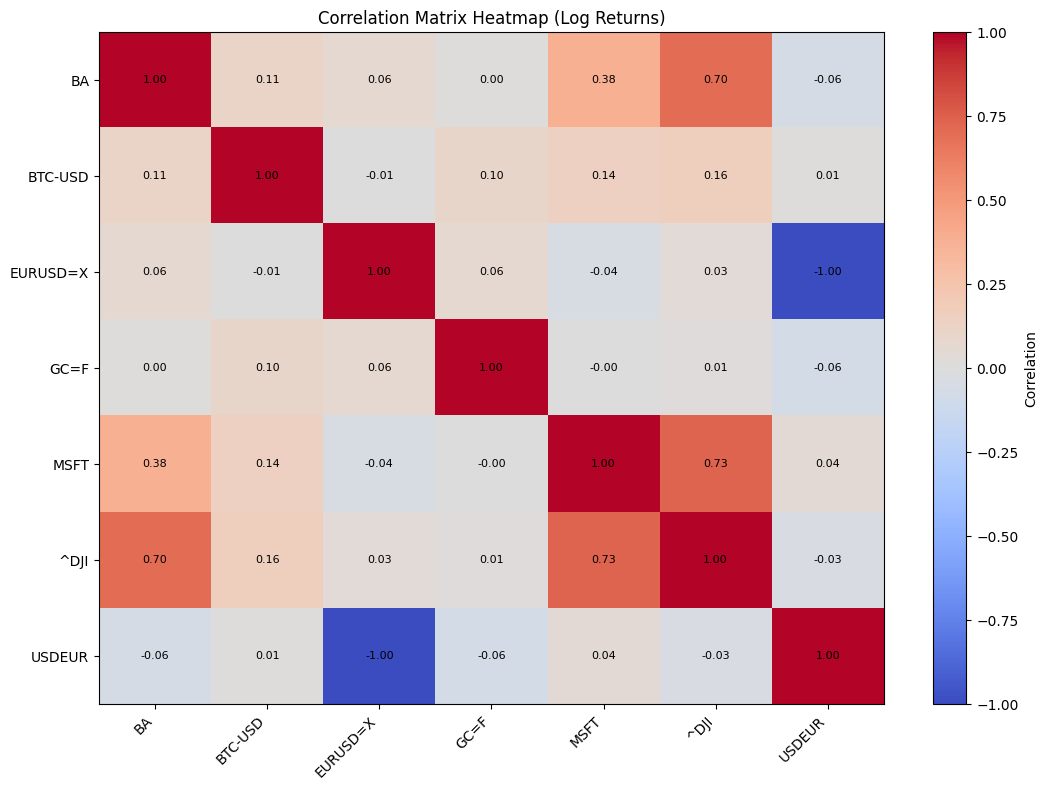

In [7]:
plt.figure(figsize=(11, 8))

if SEABORN_AVAILABLE:
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        cbar_kws={'label': 'Correlation'}
    )
else:
    # Matplotlib fallback keeps notebook runnable if seaborn is not installed.
    matrix_values = corr_matrix.values
    im = plt.imshow(matrix_values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, label='Correlation')
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
    for i in range(matrix_values.shape[0]):
        for j in range(matrix_values.shape[1]):
            plt.text(j, i, f'{matrix_values[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.title('Correlation Matrix Heatmap (Log Returns)')
plt.tight_layout()
plt.show()


## 7) Programmatic Correlation Highlights


In [8]:
diag_values = np.diag(corr_matrix.values)
print('Diagonal correlations (self-correlation, should be +1):')
print(pd.Series(diag_values, index=corr_matrix.index))

if eurusd_col is not None and 'USDEUR' in corr_matrix.columns:
    inverse_corr = corr_matrix.loc[eurusd_col, 'USDEUR']
    print(f"\nCorrelation between {eurusd_col} and USDEUR: {inverse_corr:.6f}")
    print('Expected: close to -1 for perfect inverse relationship.')
else:
    print('\nNo EURUSD/USDEUR pair available for inverse-correlation check.')

pairs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Asset_1', 'level_1': 'Asset_2', 0: 'Correlation'})
)

pairs['pair_key'] = pairs.apply(lambda r: tuple(sorted([r['Asset_1'], r['Asset_2']])), axis=1)
pairs = pairs.drop_duplicates('pair_key').drop(columns='pair_key')

high_positive = pairs.sort_values('Correlation', ascending=False).head(5)
near_zero = pairs.assign(abs_corr=pairs['Correlation'].abs()).sort_values('abs_corr').head(5).drop(columns='abs_corr')

print('\nExamples of relatively high positive correlation:')
print(high_positive.to_string(index=False))

print('\nExamples of low / near-zero correlation:')
print(near_zero.to_string(index=False))


Diagonal correlations (self-correlation, should be +1):
BA         1.000000
BTC-USD    1.000000
EURUSD=X   1.000000
GC=F       1.000000
MSFT       1.000000
^DJI       1.000000
USDEUR     1.000000
dtype: float64

Correlation between EURUSD=X and USDEUR: -1.000000
Expected: close to -1 for perfect inverse relationship.

Examples of relatively high positive correlation:
Asset_1 Asset_2  Correlation
   MSFT    ^DJI     0.727148
     BA    ^DJI     0.702869
     BA    MSFT     0.379116
BTC-USD    ^DJI     0.158476
BTC-USD    MSFT     0.141485

Examples of low / near-zero correlation:
Asset_1  Asset_2  Correlation
     BA     GC=F     0.002382
   GC=F     MSFT    -0.003697
BTC-USD   USDEUR     0.005024
BTC-USD EURUSD=X    -0.005024
   GC=F     ^DJI     0.008289


## Key Takeaways

- Similar assets often show higher positive correlation.
- Inverse or short-style relationships can show strong negative correlation.
- Assets from different classes often have lower correlation.
- Low or negative correlation can improve diversification.
- Correlation does not imply causation.


Covariance and correlation help investors quantify co-movement between assets.
Diversification aims to combine positions that do not all move in the same direction at the same time.